# Coursework Assessment: Question 3
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from OpinionModel import OpinionWorld

# Auto-reload
%load_ext autoreload
%autoreload 2

# Random Seed
SEED = 42

---
## Q3(a) - Given Model Running

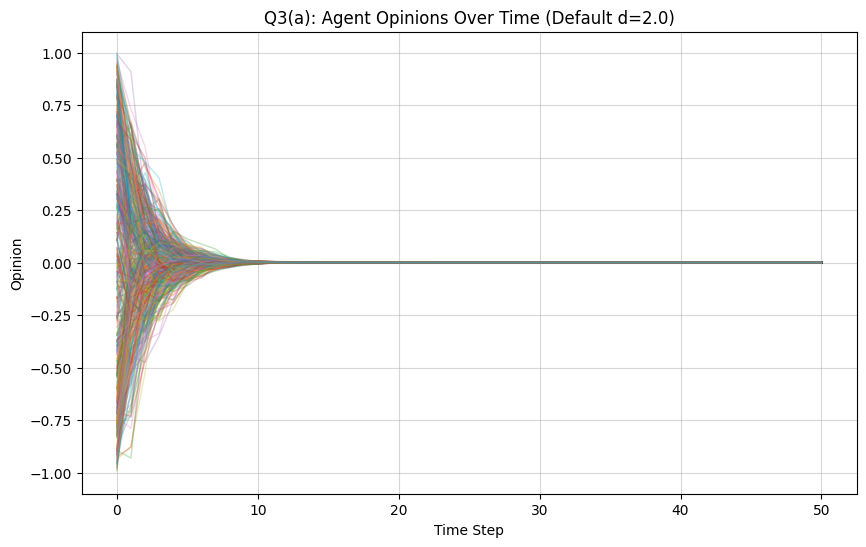

In [2]:
# ==================== Q3(a) ====================
model_a = OpinionWorld(seed=SEED) # Default confidence_threshold = 2.0 [cite: 62]

# 50 steps
for _ in range(50):
    model_a.step()

# Extract opinions Data
df_a = model_a.datacollector.get_agent_vars_dataframe()
opinions_a = df_a.unstack('AgentID')['opinion']

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(opinions_a, alpha=0.3, linewidth=1)
plt.title('Q3(a): Agent Opinions Over Time (Default d=2.0)')
plt.xlabel('Time Step')
plt.ylabel('Opinion')
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.5)
plt.show()


### Discussion:

The line plot shows clear convergence of the population opinion over time. 

Starting from a uniform spread of opinions between $[-1,1]$, the trajectories rapidly contract towards a single common value, with almost complete consensus reached within roughly 10 time-steps. 

This is expected under the default parameters because the confidence threshold is $𝑑 = 2.0$, while the maximum possible difference between any two opinions is also 2. 

Therefore, every pair of agents can influence one another, so each interaction reduces opinion differences rather than preserving separate groups. 

The model therefore behaves like repeated averaging across the whole population, causing the variance in opinions to decrease quickly and producing a final consensus close to 0, which matches the expected behavior of the default model.

---
## Q3(b)(i) - Threshold Plotting with two different confidence

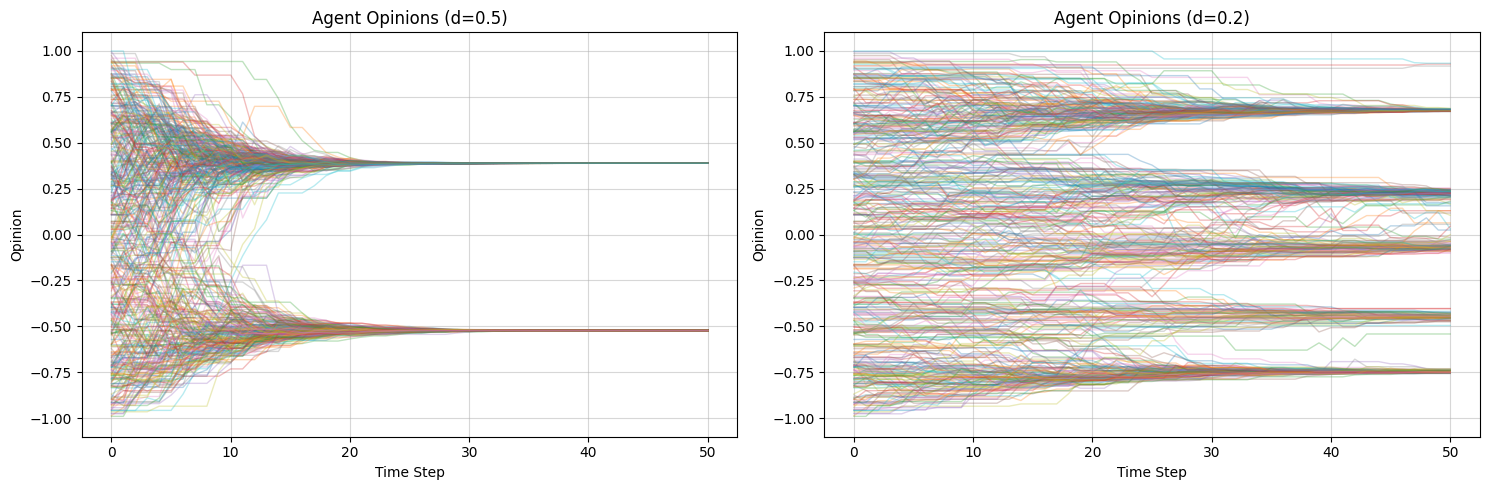

In [3]:
# ==================== Q3(b)(i) ====================
d_values_test = [0.5, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, d in enumerate(d_values_test):
    model_b = OpinionWorld(confidence_threshold=d, seed=SEED)
    for _ in range(50):
        model_b.step()
    
    df_b = model_b.datacollector.get_agent_vars_dataframe()
    opinions_b = df_b.unstack('AgentID')['opinion']
    
    axes[i].plot(opinions_b, alpha=0.3, linewidth=1)
    axes[i].set_title(f'Agent Opinions (d={d})')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Opinion')
    axes[i].set_ylim(-1.1, 1.1)
    axes[i].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### Discussion

Reducing the confidence threshold means agents only interact with others whose opinions are already fairly similar, so the population does not always reach full consensus. 

In contrast to the default case ($d=2.0$), smaller values of $d$ prevent some interactions and split the population into separate groups. 

For $d=0.5$, the opinions still converge, but into two main clusters rather than one consensus; For $d=0.2$, the population fragments further into several stable clusters. 

Overall, larger confidence thresholds promote consensus, while smaller thresholds lead to polarization and the formation of multiple opinion cliques, which is the expected behavior of the bounded confidence model. 

## Q3(b)(ii) - Relation between Number of Cliques and Confidence Threshold

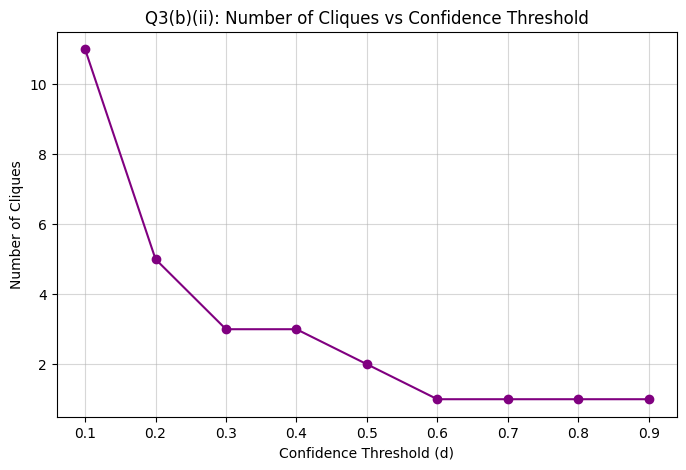

In [4]:
# ==================== Q3(b)(ii) ====================
import numpy as np
import matplotlib.pyplot as plt
from OpinionModel import OpinionWorld

SEED = 42 

# Fucntion
def ret_num_cliques(opinions, confidence_threshold):
    num_cliques = 0
    sorted_constrained_opinions = sorted([opinion for opinion in opinions if abs(opinion) <= (1 - (0.5 * confidence_threshold))])
    
    if not sorted_constrained_opinions: 
        return 0
        
    x_min = sorted_constrained_opinions[0]
    num_cliques += 1
    
    for opinion in sorted_constrained_opinions:
        if opinion > (x_min + confidence_threshold):
            x_min = opinion
            num_cliques += 1
            
    return num_cliques

# Define d searching range [0.1, 0.9]
d_range = np.arange(0.1, 1.0, 0.1)
clique_counts = []

for d in d_range:
    model_b2 = OpinionWorld(confidence_threshold=d, seed=SEED)
    for _ in range(100): # 100 steps
        model_b2.step()
    final_opinions = [a.opinion for a in model_b2.agents]
    clique_counts.append(ret_num_cliques(final_opinions, d))

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(d_range, clique_counts, marker='o', linestyle='-', color='purple')
plt.title('Q3(b)(ii): Number of Cliques vs Confidence Threshold')
plt.xlabel('Confidence Threshold (d)')
plt.ylabel('Number of Cliques')
plt.grid(True, alpha=0.5)
plt.show()

---
## Q3(c)(i) - The effect of neighborhood size on opinion dynamics

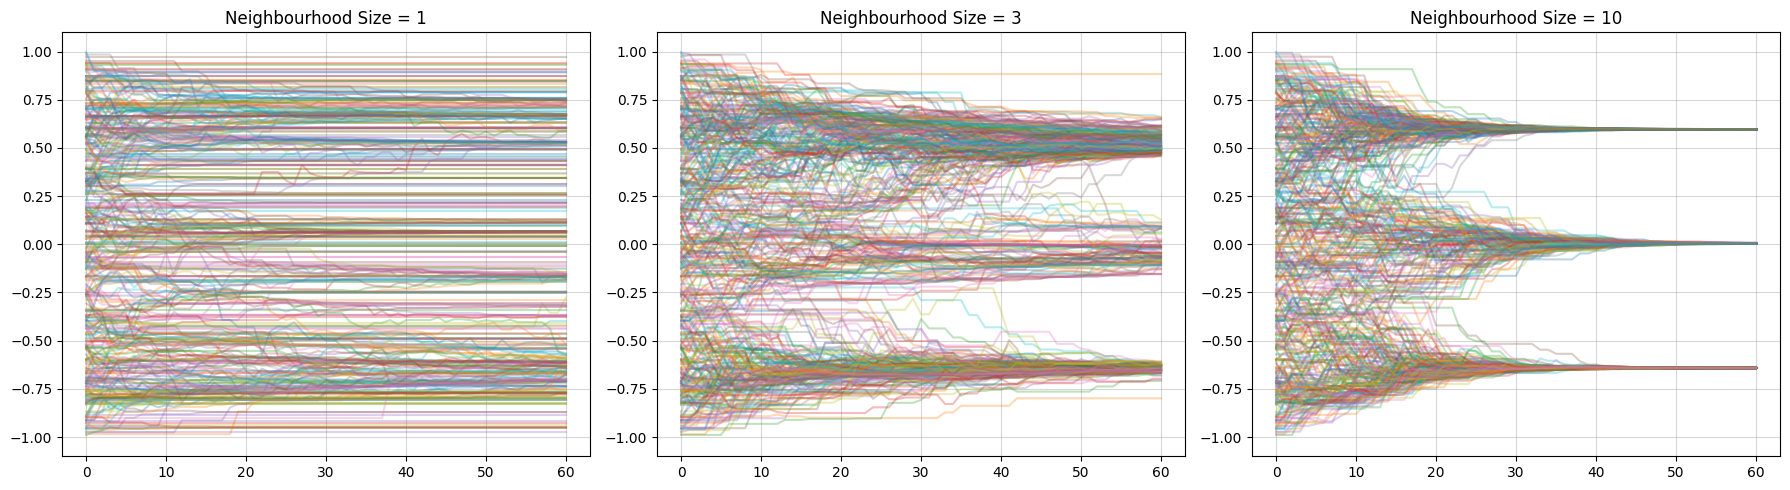

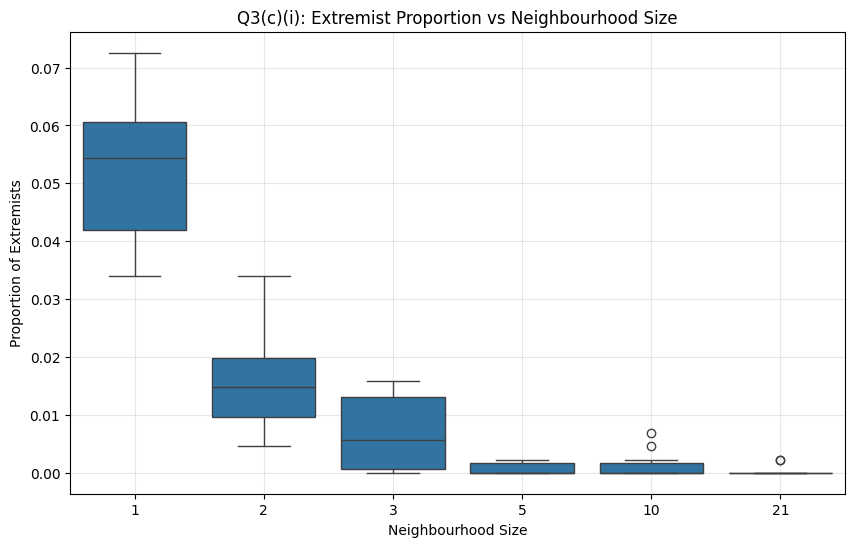

In [5]:
# ==================== Q3(c)(i) ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from OpinionModel import OpinionWorld

SEED = 42
fixed_d = 0.3
test_neighborhoods = [1, 3, 10]

# 1. Plotting opinion trajectories for different neighborhood sizes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, n_size in enumerate(test_neighborhoods):
    model_c = OpinionWorld(confidence_threshold=fixed_d, neighbourhood_size=n_size, seed=SEED)
    for _ in range(60):
        model_c.step()
    df_c = model_c.datacollector.get_agent_vars_dataframe().unstack('AgentID')['opinion']
    axes[i].plot(df_c, alpha=0.3)
    axes[i].set_title(f'Neighbourhood Size = {n_size}')
    axes[i].set_ylim(-1.1, 1.1)
    axes[i].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Plotting boxplots of extremist proportions for multiple runs
runs_per_condition = 10  # Runs per condition (10 times) for boxplot sampling
n_sizes_box = [1, 2, 3, 5, 10, 21]
extremist_data = []

for n_size in n_sizes_box:
    for run in range(runs_per_condition):
        # Use random seed for each run
        model_box = OpinionWorld(confidence_threshold=fixed_d, neighbourhood_size=n_size, seed=SEED+run)
        for _ in range(50):
            model_box.step()
        df_model = model_box.datacollector.get_model_vars_dataframe()
        final_extremists = df_model['proportion_of_extremists'].iloc[-1]
        extremist_data.append({'Neighbourhood Size': n_size, 'Proportion of Extremists': final_extremists})

    # Plotting (boxplots)
df_box = pd.DataFrame(extremist_data)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Neighbourhood Size', y='Proportion of Extremists', data=df_box)
plt.title('Q3(c)(i): Extremist Proportion vs Neighbourhood Size')
plt.grid(True, alpha=0.3)
plt.show()

### Comment

With $d=0.3$, increasing neighborhood size makes opinions mix more widely across the population. 

For small neighborhoods, agents mostly interact locally, so opinions remain more spread out and extreme values persist. 

As neighborhood size increases, the trajectories cluster more tightly and the final proportion of extremists falls. 

Larger neighborhoods therefore reduce extremism, although full consensus is still limited by the relatively small confidence threshold.

## Q3(c)(ii) Design Choices Description and Discussion

In the default model, “space” is implemented as a simple local structure, so agents interact only with others in a limited neighborhood rather than with the whole population. 

This is easy to implement and makes the effect of local interaction clear, but it is a simplified representation of real social systems. 

A network-based approach would treat agents as nodes and social links as edges, with each agent interacting only with its connected neighbors. 

This would be more flexible and realistic, because it could represent features such as clusters, hubs, and long-range connections that a simple neighborhood model cannot capture well.


---
## Q3(d) - Testing with custom distribution

### Discussion

The assumption of a uniform initial opinion distribution is not realistic, as it implies that extreme and moderate opinions are equally common. 

In practice, opinions are often more concentrated around moderate values or biased towards one side. 

However, it is still a useful baseline assumption as it introduces no initial bias, so any later consensus or clustering is caused by the interaction rules rather than the starting distribution. 

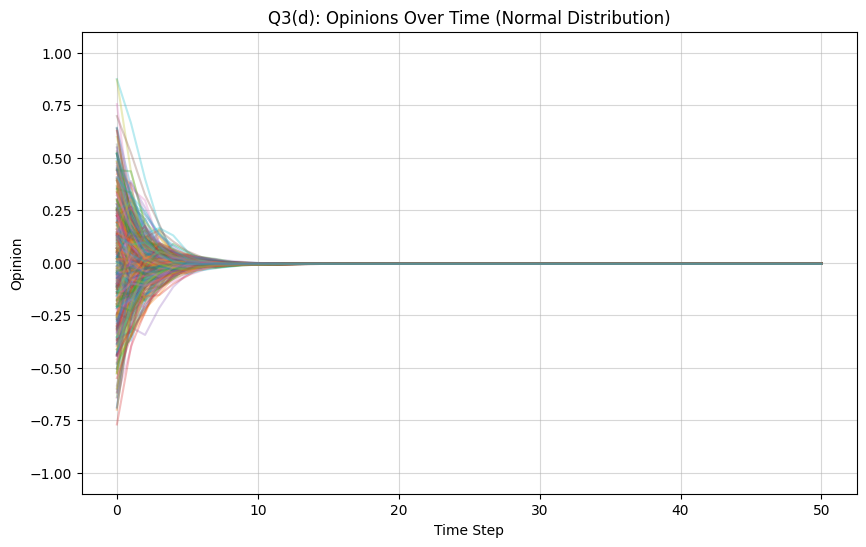

In [6]:
# ==================== Q3(d) ====================
import numpy as np
import matplotlib.pyplot as plt
from OpinionModel import OpinionWorld

SEED = 42

# Running model with normal distribution initialization
model_d = OpinionWorld(initialisation_type="normal", seed=SEED)

for _ in range(50):
    model_d.step()

df_d = model_d.datacollector.get_agent_vars_dataframe().unstack('AgentID')['opinion']

plt.figure(figsize=(10, 6))
plt.plot(df_d, alpha=0.3)
plt.title('Q3(d): Opinions Over Time (Normal Distribution)')
plt.xlabel('Time Step')
plt.ylabel('Opinion')
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.5)
plt.show()

---
## Q3(e) - Stubborn Voters Simulation

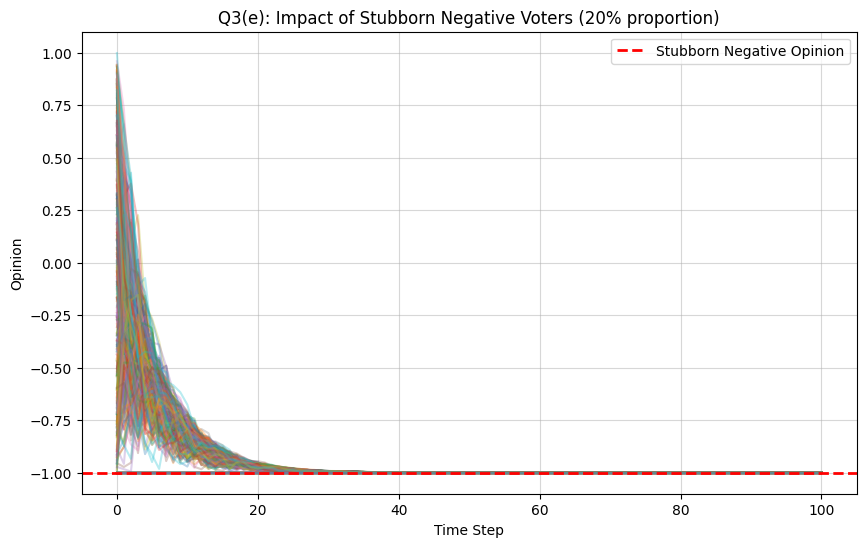

In [7]:
# ==================== Q3(e) ====================
import numpy as np
import matplotlib.pyplot as plt
from OpinionModel import OpinionWorld

SEED = 42

# Assuming 20% of the population are stubborn negative voters (stubborn_proportion=0.2)
model_e = OpinionWorld(initialisation_type="stubborn", stubborn_proportion=0.2, seed=SEED)

for _ in range(100):
    model_e.step()

df_e = model_e.datacollector.get_agent_vars_dataframe().unstack('AgentID')['opinion']

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df_e, alpha=0.3)
plt.axhline(y=-1, color='red', linestyle='--', linewidth=2, label='Stubborn Negative Opinion')
plt.title('Q3(e): Impact of Stubborn Negative Voters (20% proportion)')
plt.xlabel('Time Step')
plt.ylabel('Opinion')
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## Discussion

 - Description 
    
    A new `stubborn` option is added to `initialisation_type`so the model can switch between the default setup and a stubborn-voter setup. 
    
    A `stubborn_proportion` parameter is also used to control how many agents are stubborn negative voters, which is tested with `initialisation_type="stubborn"` and `stubborn_proportion=0.2`.

- Explanation

    This design keeps the original model unchanged while making it easy to test the hypothesis by only changing the initialization. 
    
    The stubborn voters represent agents with strongly negative opinions who do not change their view after interacting with others, while the remaining agents still follow the normal opinion-update rule. 
    
    Using a separate proportion parameter also makes it easy to explore how many stubborn negative voters are needed to push the final consensus below zero. 

- Algorithm Verifaction

    The implementation is verified by running the stubborn version of the model for 100 time-steps with a fixed seed (`seed=42`) and plotting all opinion trajectories. 
    
    The plot includes a reference line at $y=-1$, thus checking whether stubborn negative voters stayed fixed at the negative extreme while the rest of the population evolved around them. 
    
    This showed that the stubborn behavior was active and that it changed the overall opinion dynamics as intended.